# Human Eye Quantum Efficiency

The human eye uses rod and cone cells in the retina to sense light.  Cone cells are responsible for color vision
and most sensitive at bright light levels, whereas the rod cells are more sensitive at low light levels and
monochromatic in their response.

There are thus two luminous efficiency curves for the human eye:
 * Photopic Sensitivity: normal light levels, nominal peak QE 0.5%
 * Scotopic Sensitivity: low light levels, nominal peak QE 5%
 
The normalized luminous efficiencies we plot are
 * Photopic: [Sharpe, Stockman, Jagla, & Jaegle (2005)](https://jov.arvojournals.org/article.aspx?articleid=2121738)
 * Scotopic: CIE 1951

A fun technical read about how this is measured is van Meeteren, 1997, Vision Res, 18, 257 [https://www.sciencedirect.com/science/article/abs/pii/0042698978901608?via%3Dihub] (yes, I, too, think papers older than 20 years should be in the public domain. Thanks, Elsevier).


In [5]:
%matplotlib inline

import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Plot Setup

In [6]:
figName = 'HumanEye_QE' 

# aspect is the aspect ratio, width/height
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
# textWidth is the width of the text defining the maximum width
#

#aspect = 4./3. # letter
aspect = 16./9. # wide screen

fPage = 1.0
scaleFac = 0.85
textWidth = 6.0 # inches

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
   
# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']='%d' % (axisPad)
plt.rcParams['ytick.major.pad']='%d' % (axisPad)
plt.rcParams['axes.labelpad'] = '%d' % (axisPad)

## Data Files

Data are in ASCII multi-column format with a simple text header.  Read using the pandas read_csv() method.

In [7]:
# CIE 1951 Scotopic Luminous Efficiency

dataFile = 'HumanEyeScotopic_CIE1951.txt'
data = pd.read_csv(dataFile,sep=r'\s+',comment='#')
lSco = np.array(data['lam'])
vSco = np.array(data['Vlam'])
qeSco = 0.05*vSco

# Sharpe et al. 2005 Photopic Luminous Efficiency

dataFile = 'HumanEyePhotopic_SSJJ2005.txt'
data = pd.read_csv(dataFile,sep=r'\s+',comment='#')
lPho = np.array(data['lam'])
vPho = np.array(data['Vlam'])
qePho = 0.005*vPho

# Plotting limits

xMin = 350.
xMax = 750.
yMin = 1.0e-6
yMax = 1.0

## Plot QE curves

Plot QE curves on top of each other in a logarithmic scale.

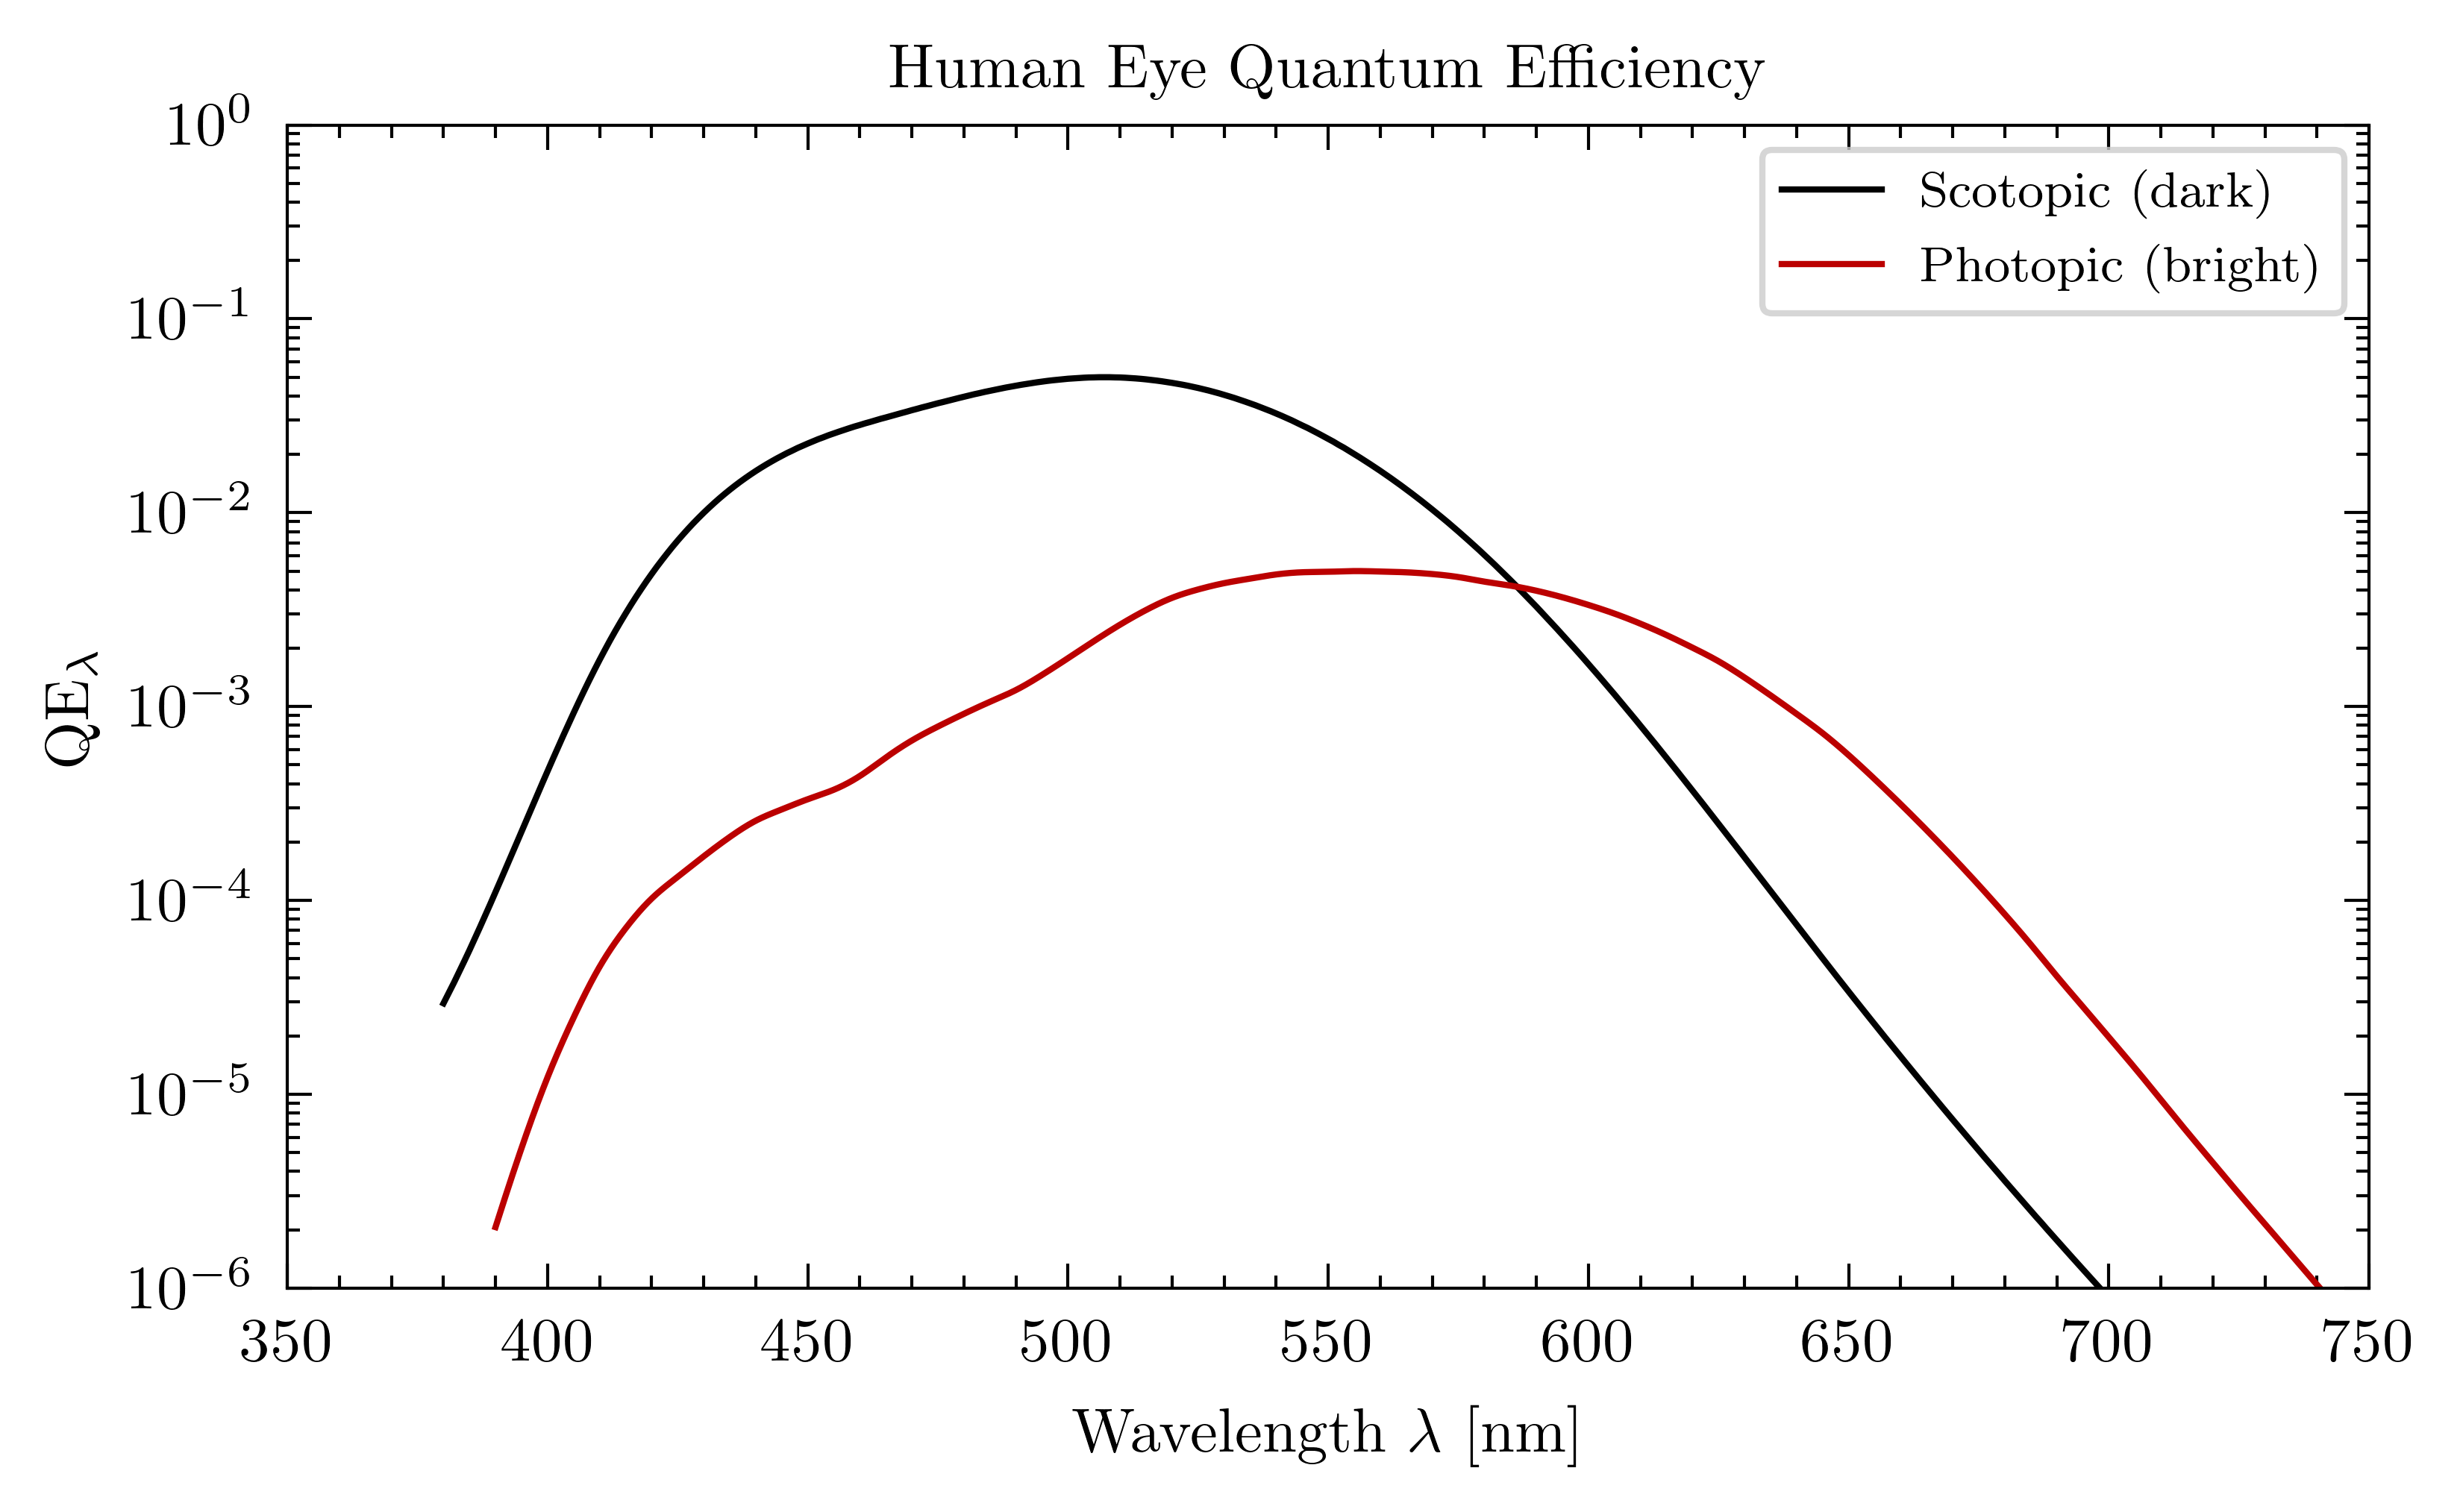

In [13]:
fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=4,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top='on',right='on')
    
# Limits

ax.set_xlim(xMin,xMax)
ax.xaxis.set_major_locator(MultipleLocator(50))
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.set_xlabel(r'Wavelength $\lambda$ [nm]',fontsize=axisFontSize)

ax.set_ylim(yMin,yMax)
ax.set_yscale('log')
ax.set_ylabel(r'QE$_\lambda$',fontsize=axisFontSize)

ax.plot(lSco,qeSco,'-',lw=1,color='black',label='Scotopic (dark)')
ax.plot(lPho,qePho,'-',lw=1,color='#bb0000',label='Photopic (bright)')
    
ax.set_title('Human Eye Quantum Efficiency',fontsize=axisFontSize)
ax.legend(fontsize=labelFontSize)

plt.savefig(f"{figName}_log.{figFmt}",bbox_inches='tight',facecolor='white')
plt.show()


### Linear scale


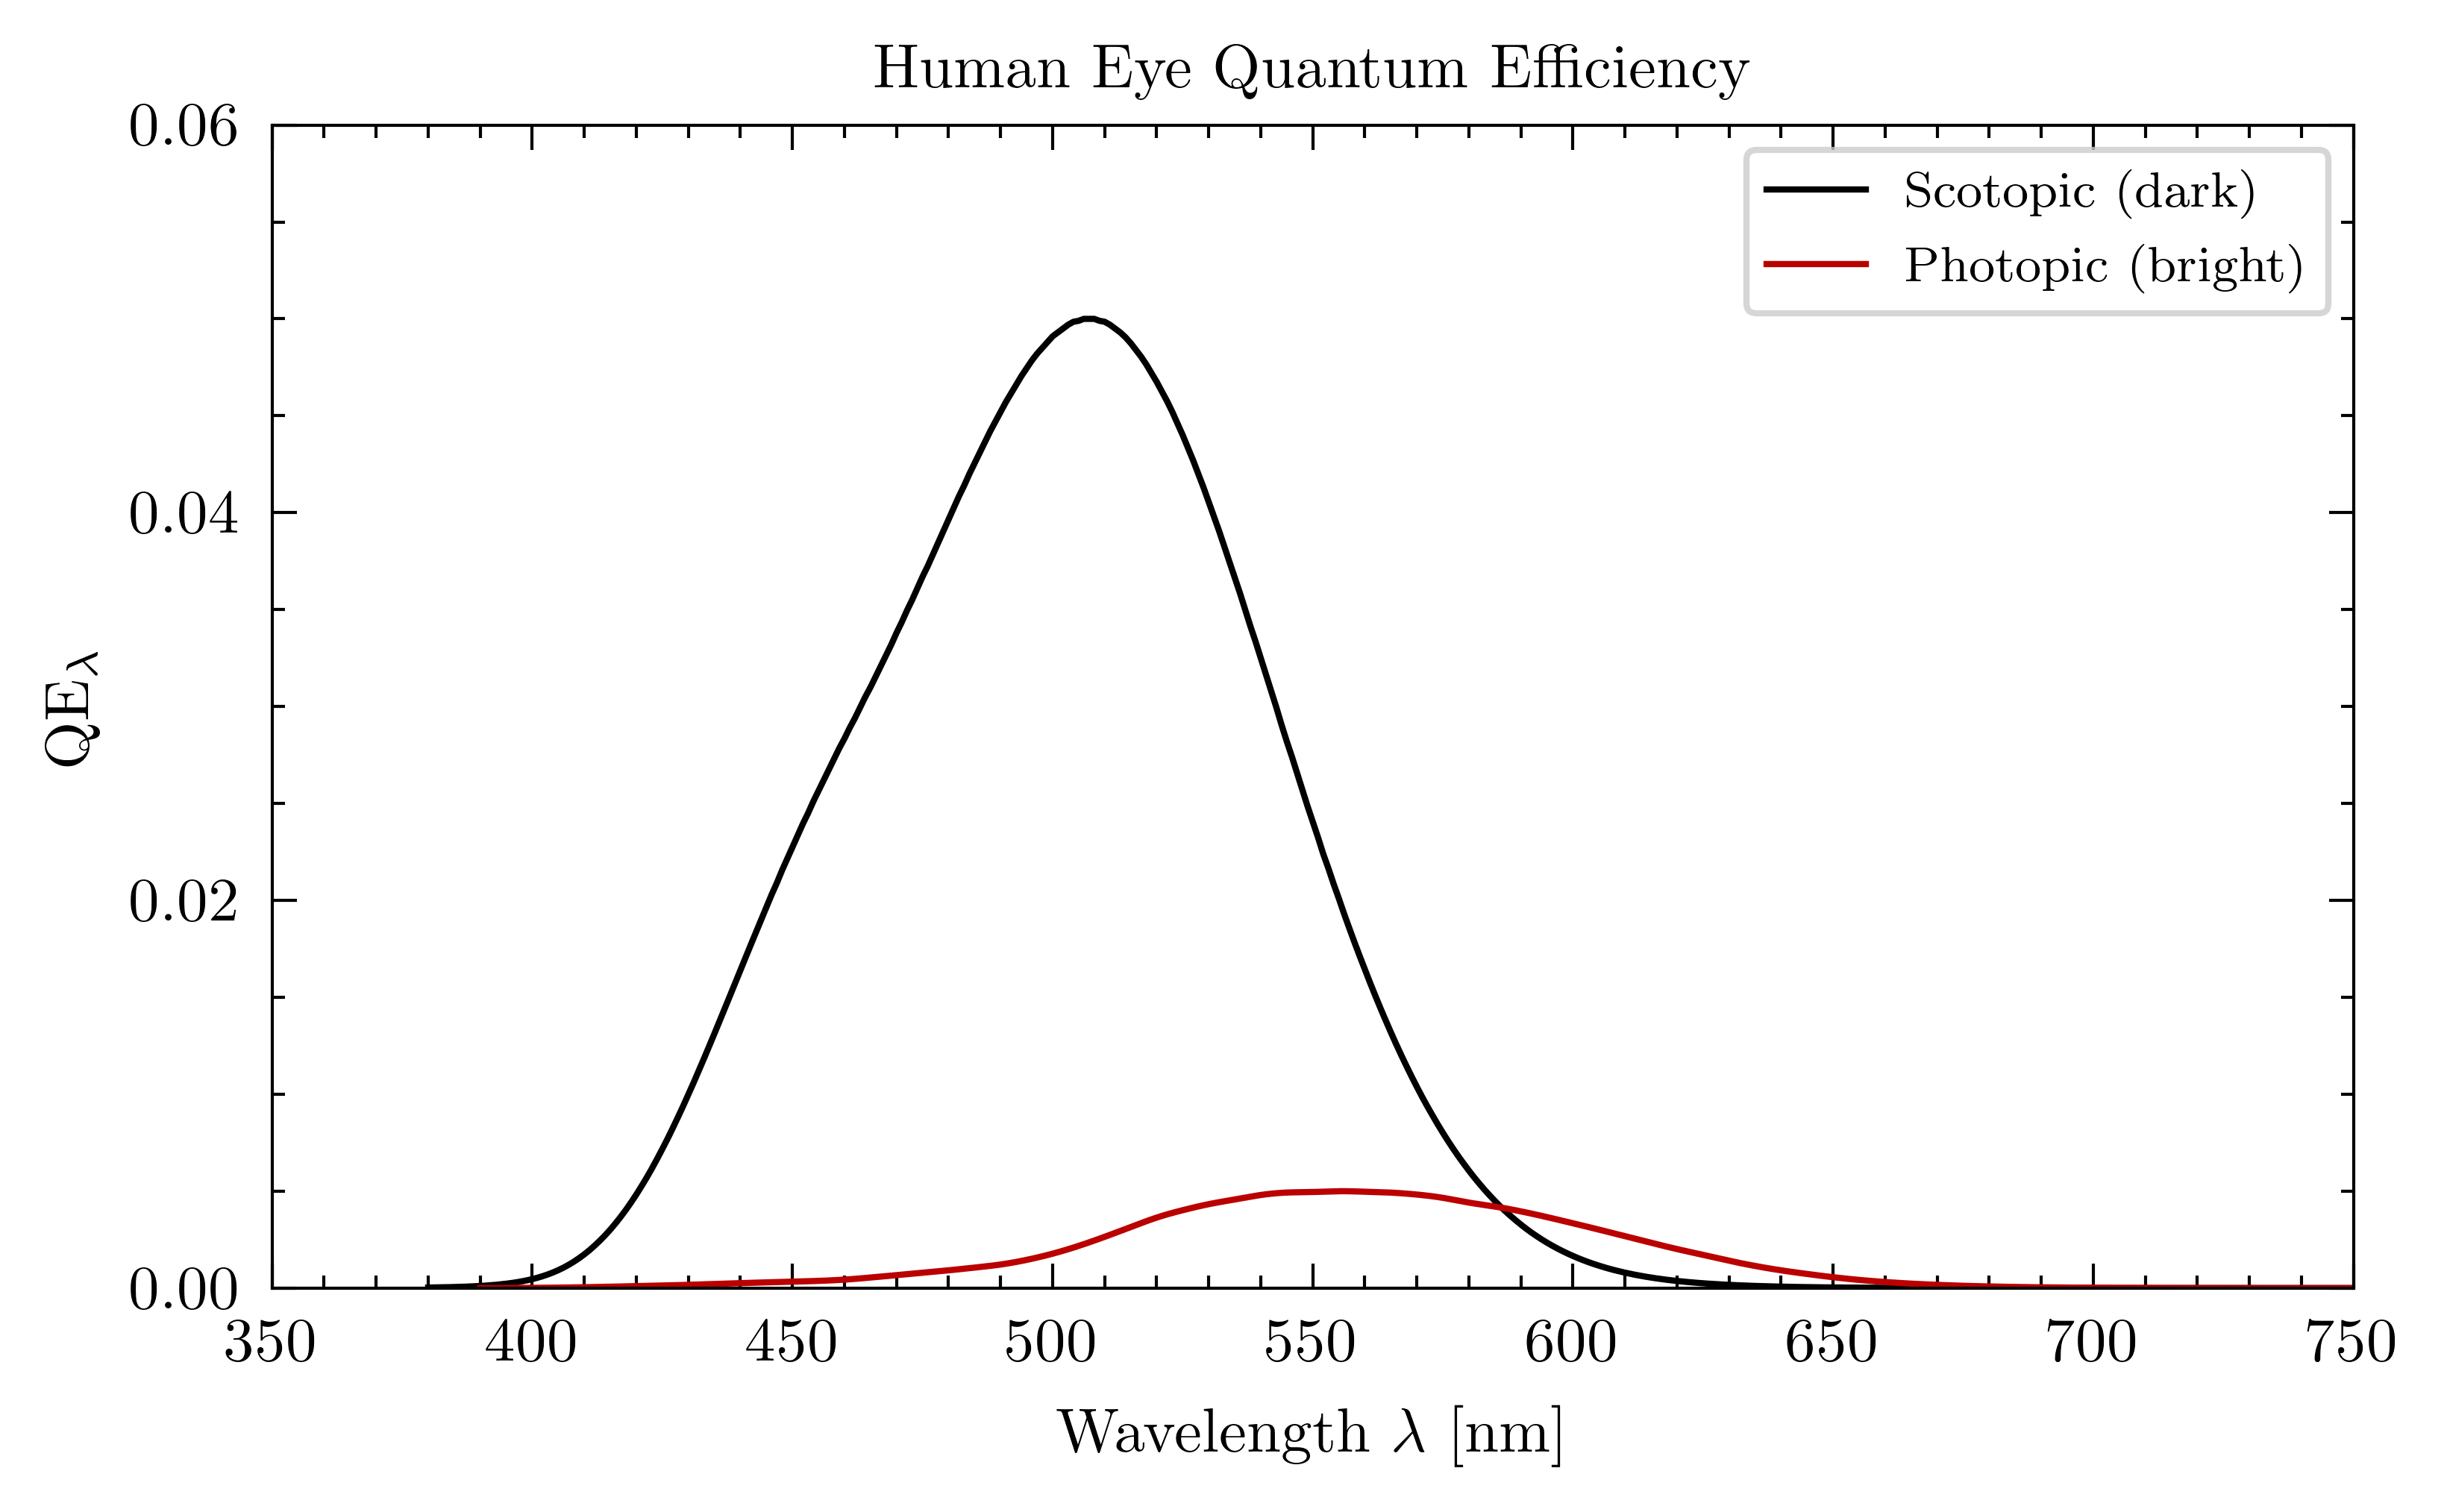

In [14]:
fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=4,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top='on',right='on')
    
# Limits

ax.set_xlim(xMin,xMax)
ax.xaxis.set_major_locator(MultipleLocator(50))
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.set_xlabel(r'Wavelength $\lambda$ [nm]',fontsize=axisFontSize)

ax.set_ylim(0.0,0.06)
ax.yaxis.set_major_locator(MultipleLocator(0.02))
ax.yaxis.set_minor_locator(MultipleLocator(0.005))
ax.set_ylabel(r'QE$_\lambda$',fontsize=axisFontSize)

ax.plot(lSco,qeSco,'-',lw=1,color='black',label='Scotopic (dark)')
ax.plot(lPho,qePho,'-',lw=1,color='#bb0000',label='Photopic (bright)')
    
ax.set_title('Human Eye Quantum Efficiency',fontsize=axisFontSize)
ax.legend(fontsize=labelFontSize)

plt.savefig(f"{figName}_linear.{figFmt}",bbox_inches='tight',facecolor='white')
plt.show()